In [ ]:
# ==========================================
# Cell 1: 导入依赖与初始化模型
# ==========================================

%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import os
import torch
import numpy as np
import warnings
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)

from configs.default_config import Config
from envs.hems_env import EnergyStorageEnv
from common.replay_buffer import ReplayBuffer
from madrl.maddpg import MADDPG
from madrl.matd3 import MATD3
from common.vec_env import DummyVecEnv


# ---------------- 配置测试参数 ----------------
TEST_START_DAY = 0        # 测试起始天数 (n)
TEST_DAYS = 20            # 连续测试的天数
LOAD_EPISODE = 992       # 你想加载的模型所对应的训练代数 (请根据实际保存的pth文件修改)
ALGORITHM = "MADDPG"      # 使用的算法
MODEL_DIR = f"./saved_models/{ALGORITHM}" # 模型所在路径

# ---------------- 初始化 ----------------
args = Config()
args.algorithm = ALGORITHM
# 测试时无需探索
args.use_noise_decay = False 
args.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=> 初始化测试环境 (Mode: test)...")
# 测试时直接使用原始环境，便于指定 episode_idx
env = EnergyStorageEnv(args, mode='test')

# 补齐 Agent 维度参数
args.N = env.n
args.obs_dim_n = [env.observation_space[i].shape[0] for i in range(args.N)]
args.action_dim_n = [env.action_space[i].shape[0] for i in range(args.N)]

print("=> 加载训练好的多智能体模型...")
agents = [MADDPG(args, i) for i in range(args.N)]
for agent in agents:
    agent.load_model(MODEL_DIR, LOAD_EPISODE)
    
print("✅ 模型加载成功！准备开始测试。")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
=> 初始化测试环境 (Mode: test)...
=> 加载训练好的多智能体模型...
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------


FileNotFoundError: [Errno 2] No such file or directory: './saved_models/MADDPG\\actor_agent_0_ep_1000.pth'

In [8]:
# ==========================================
# Cell 2: 执行测试并输出指标表格 (已修复 Key 兼容性)
# ==========================================
test_results = []
metrics_list = []

print(f"=> 开始执行测试: 第 {TEST_START_DAY} 天 至 第 {TEST_START_DAY + TEST_DAYS - 1} 天")

for day_idx in range(TEST_START_DAY, TEST_START_DAY + TEST_DAYS):
    obs_n = env.reset(episode_idx=day_idx)
    
    # 记录当天的临时数据
    day_data = {
        'price': [], 'orig_load': [], 'net_load': [],
        'e_bat': {i: [] for i in range(args.N)},
        'soc': {i: [env.init_soc] for i in range(args.N)}, # 预存初始SOC
        'daily_profit': 0.0
    }
    
    for step in range(args.episode_limit):
        a_n = []
        # 遍历每个智能体进行前向推理 (Zero Noise for Testing)
        for i in range(args.N):
            obs_batch = np.expand_dims(obs_n[i], axis=0)
            a_batch = agents[i].choose_action(obs_batch, noise_std=0.0)
            a_n.append(a_batch[0]) 
            
        obs_next_n, rewards, done_n, info = env.step(a_n)
        
        # ---------------- ★ 核心修复区 ★ ----------------
        price = info['price']
        e_bat_arr = info['e_bat']        # shape: (N,)
        net_load_arr = info['net_load']  # shape: (N,)
        
        # 还原计算全局宏观指标
        orig_load_arr = net_load_arr - e_bat_arr
        orig_total = np.sum(orig_load_arr)
        net_total = np.sum(net_load_arr)
        # 套利利润：放电(e_bat<0)时赚钱，所以是 -e_bat * price
        step_profit = np.sum(-e_bat_arr * price) 
        
        # 数据记录
        day_data['price'].append(price)
        day_data['orig_load'].append(orig_total)
        day_data['net_load'].append(net_total)
        day_data['daily_profit'] += step_profit
        
        for i in range(args.N):
            day_data['e_bat'][i].append(e_bat_arr[i]) 
            day_data['soc'][i].append(info['soc_next'][i]) 
            
        obs_n = obs_next_n

    test_results.append(day_data)
    
    # 计算当天的峰谷差改善
    orig_pv_diff = np.max(day_data['orig_load']) - np.min(day_data['orig_load'])
    net_pv_diff = np.max(day_data['net_load']) - np.min(day_data['net_load'])
    pv_improvement = orig_pv_diff - net_pv_diff
    
    metrics_list.append({
        'Day': day_idx,
        'Daily Profit (€/¥)': round(day_data['daily_profit'], 2),
        'Original P-V Diff (kW)': round(orig_pv_diff, 2),
        'Net P-V Diff (kW)': round(net_pv_diff, 2),
        'P-V Improvement (kW)': round(pv_improvement, 2)
    })

# ---------------- 汇总成表格 ----------------
df_metrics = pd.DataFrame(metrics_list)
df_metrics.set_index('Day', inplace=True)

total_profit = df_metrics['Daily Profit (€/¥)'].sum()
avg_daily_profit = df_metrics['Daily Profit (€/¥)'].mean()
avg_pv_improvement = df_metrics['P-V Improvement (kW)'].mean()

print("\n" + "="*50)
print(f"📊 连续 {TEST_DAYS} 天测试核心指标汇总")
print("="*50)
print(f"💰 储能总收益 (Total Profit): {total_profit:.2f}")
print(f"💸 平均每日收益 (Avg Daily Profit): {avg_daily_profit:.2f}")
print(f"📉 平均每日峰谷差改善 (Avg P-V Improvement): {avg_pv_improvement:.2f}")
print("="*50 + "\n")

# 展示表格
display(df_metrics)

=> 开始执行测试: 第 0 天 至 第 19 天

📊 连续 20 天测试核心指标汇总
💰 储能总收益 (Total Profit): 3339.17
💸 平均每日收益 (Avg Daily Profit): 166.96
📉 平均每日峰谷差改善 (Avg P-V Improvement): -0.32



,Daily Profit (€/¥),Original P-V Diff (kW),Net P-V Diff (kW),P-V Improvement (kW)
Day,,,,
0,197.699997,0.84,0.98,-0.14
1,116.029999,1.01,1.39,-0.37
2,159.589996,0.90,0.88,0.03
3,84.190002,0.79,1.36,-0.57
4,0.420000,0.84,1.27,-0.43
5,150.119995,1.16,1.76,-0.59
6,129.960007,0.84,1.30,-0.45
7,275.950012,1.12,1.43,-0.31
8,341.269989,0.85,1.20,-0.35


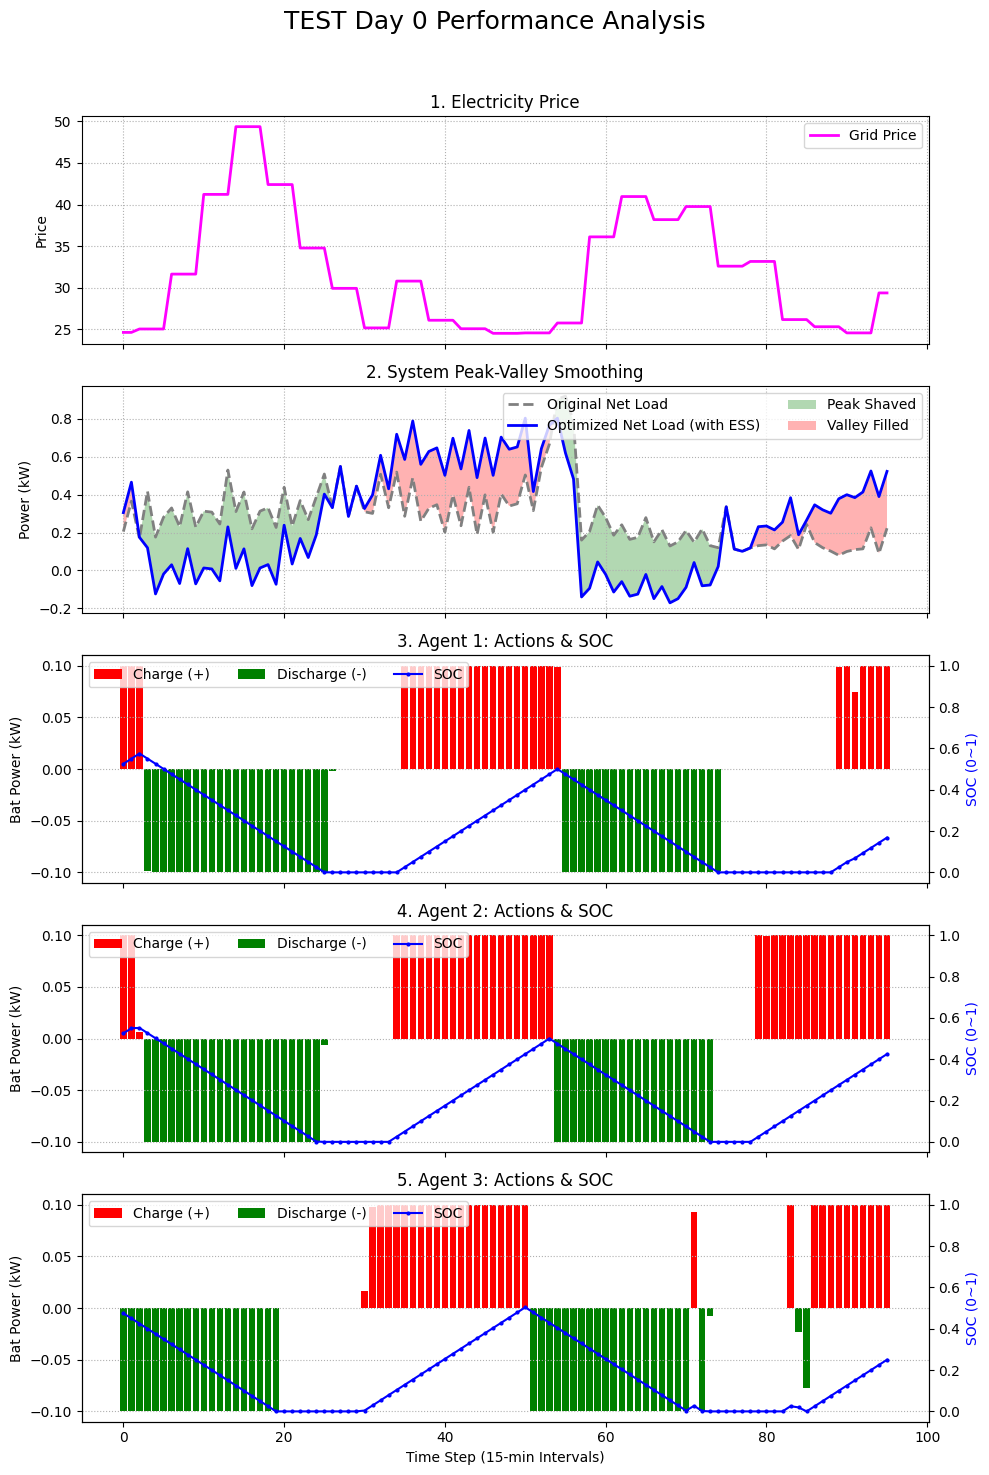

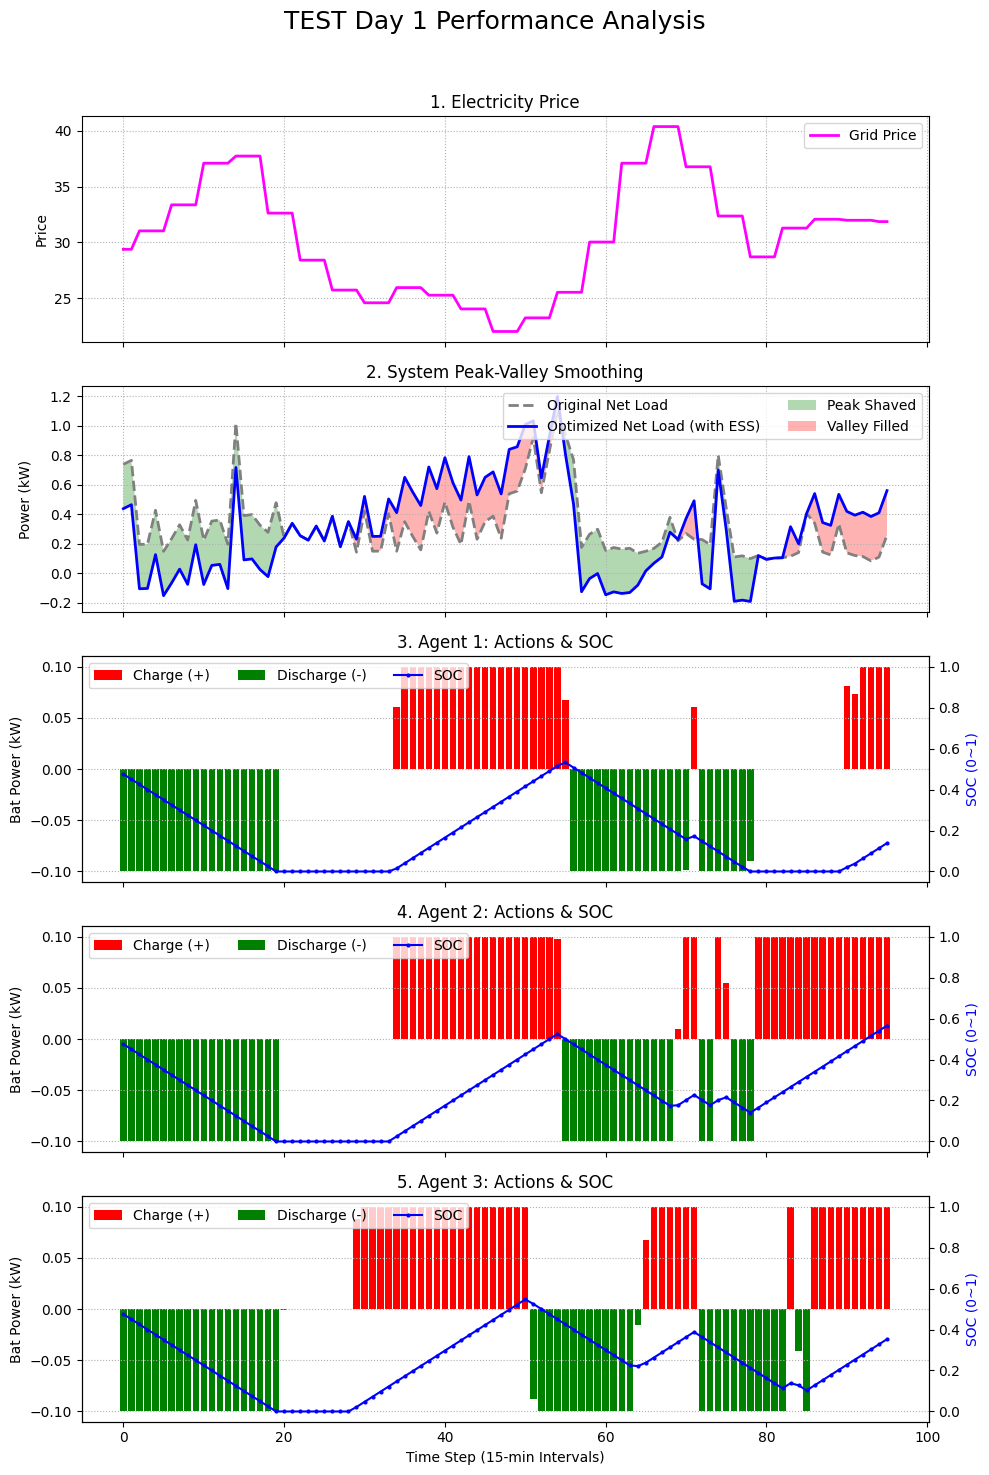

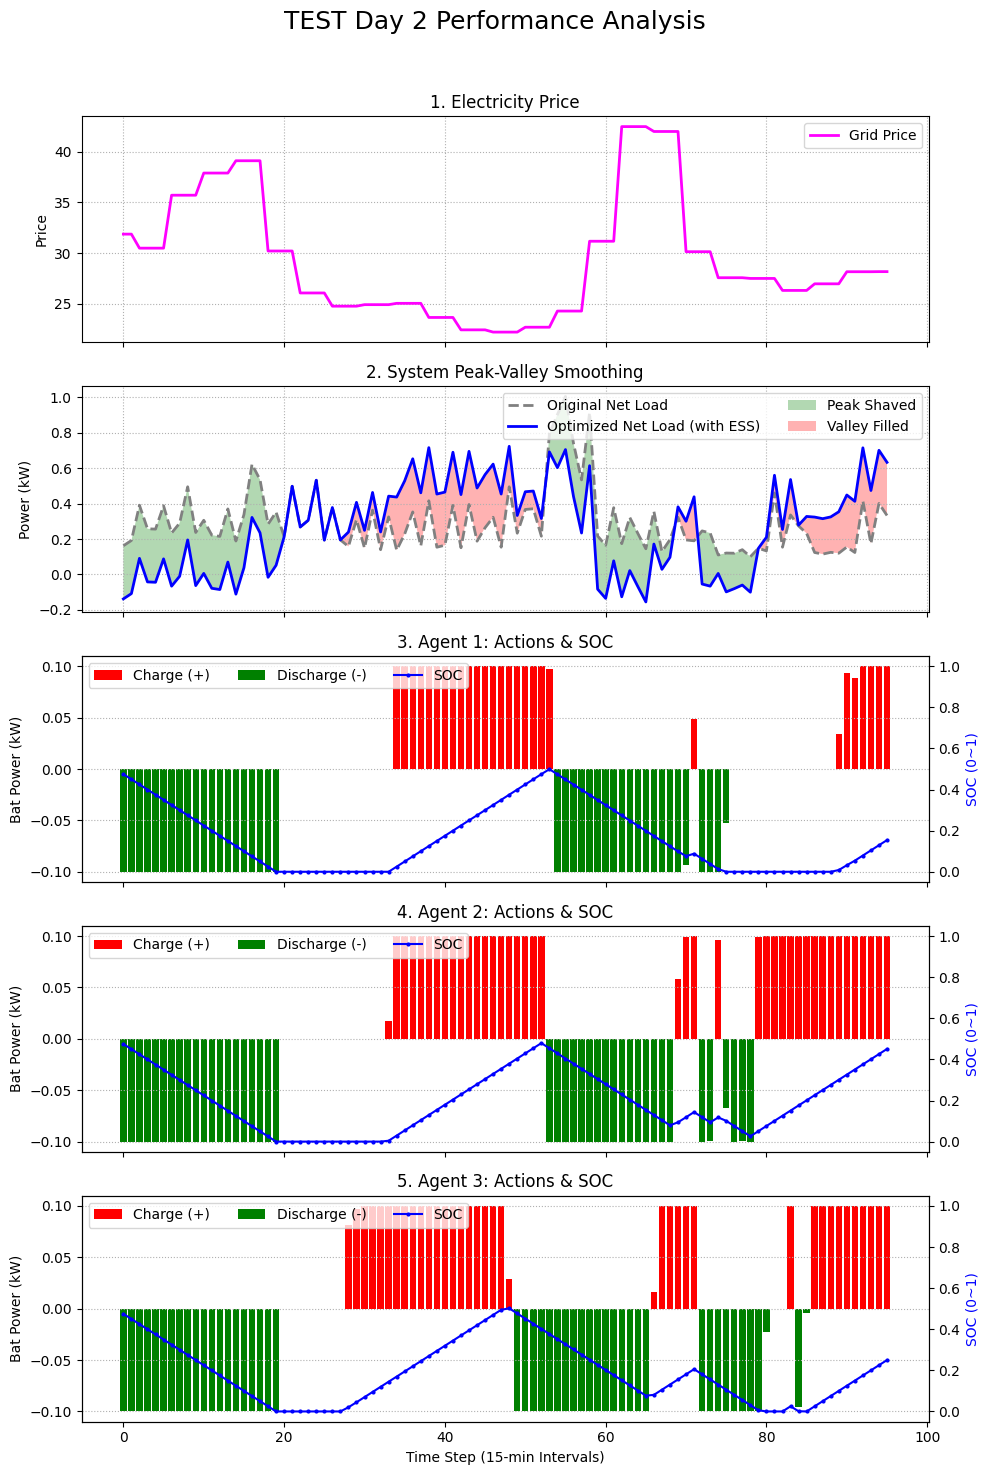

In [9]:
# ==========================================
# Cell 3: 绘制前 3 天的详细性能分析图
# ==========================================

DAYS_TO_PLOT = min(3, TEST_DAYS)
time_steps = np.arange(args.episode_limit)

for i_day in range(DAYS_TO_PLOT):
    day_data = test_results[i_day]
    actual_day_idx = TEST_START_DAY + i_day
    
    # 创建画布: 2(全局指标) + N(各个智能体) 个子图
    fig, axs = plt.subplots(2 + args.N, 1, figsize=(10, 3 * (2 + args.N)), sharex=True)
    fig.suptitle(f'TEST Day {actual_day_idx} Performance Analysis', fontsize=18, y=0.98)
    
    # ---------------- 子图 1: 电价 ----------------
    ax_price = axs[0]
    ax_price.plot(time_steps, day_data['price'], color='magenta', linewidth=2, label='Grid Price')
    ax_price.set_ylabel('Price')
    ax_price.set_title('1. Electricity Price')
    ax_price.grid(True, linestyle=':')
    ax_price.legend(loc='upper right')
    
    # ---------------- 子图 2: 负荷峰谷对比 ----------------
    ax_load = axs[1]
    ax_load.plot(time_steps, day_data['orig_load'], color='grey', linestyle='--', linewidth=2, label='Original Net Load')
    ax_load.plot(time_steps, day_data['net_load'], color='blue', linewidth=2, label='Optimized Net Load (with ESS)')
    ax_load.set_ylabel('Power (kW)')
    ax_load.set_title('2. System Peak-Valley Smoothing')
    
    # 填充改善区域让效果更直观
    ax_load.fill_between(time_steps, day_data['orig_load'], day_data['net_load'], 
                         where=(np.array(day_data['net_load']) < np.array(day_data['orig_load'])), 
                         facecolor='green', alpha=0.3, interpolate=True, label='Peak Shaved')
    ax_load.fill_between(time_steps, day_data['orig_load'], day_data['net_load'], 
                         where=(np.array(day_data['net_load']) > np.array(day_data['orig_load'])), 
                         facecolor='red', alpha=0.3, interpolate=True, label='Valley Filled')
    
    ax_load.grid(True, linestyle=':')
    ax_load.legend(loc='upper right', ncol=2)
    
    # ---------------- 子图 3~5: 智能体充放电与SOC ----------------
    for ag_id in range(args.N):
        ax_agent = axs[2 + ag_id]
        
        # 动作条形图 (Bar)
        e_bat_arr = np.array(day_data['e_bat'][ag_id])
        # 充电 (正) 用红色，放电 (负) 用绿色
        ax_agent.bar(time_steps, np.maximum(0, e_bat_arr), color='red', width=0.8, label='Charge (+)')
        ax_agent.bar(time_steps, np.minimum(0, e_bat_arr), color='green', width=0.8, label='Discharge (-)')
        ax_agent.set_ylabel('Bat Power (kW)', color='black')
        ax_agent.set_title(f'{3+ag_id}. Agent {ag_id+1}: Actions & SOC')
        ax_agent.grid(True, axis='y', linestyle=':')
        
        # SOC 曲线图 (Twinx)
        ax_soc = ax_agent.twinx()
        # 注意：SOC长度是 97，画图时取 [1:] 对应 step 1~96 的末端状态
        soc_arr = np.array(day_data['soc'][ag_id][1:]) 
        ax_soc.plot(time_steps, soc_arr, color='blue', marker='.', markersize=4, linewidth=1.5, label='SOC')
        ax_soc.set_ylabel('SOC (0~1)', color='blue')
        ax_soc.set_ylim(-0.05, 1.05)
        
        # 合并图例
        lines_1, labels_1 = ax_agent.get_legend_handles_labels()
        lines_2, labels_2 = ax_soc.get_legend_handles_labels()
        ax_agent.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', ncol=3)
        
    axs[-1].set_xlabel('Time Step (15-min Intervals)')
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()